In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [9]:
#---------------
# problem: 
#---------------
# How accurately can we predict diamond carat weight from dimensions? (x, y, z) --> carat weight

#---------------
# load data
#---------------
diamond = sns.load_dataset('diamonds')
print(diamond.head())
print('='*50)
print(diamond.shape)
print('='*50)
print(diamond.info())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
(53940, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-

In [25]:
#---------------
# data split & scaling
#---------------
X, y = diamond[['x', 'y', 'z']], diamond['carat']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# we do scaling after split because the test data may accidentally influence the training process
scalar = StandardScaler()
# we use fit + tranform because "it learns parameters (mean, std) from the data then transform! default: (x - mean) /std"
X_train_tranformed = scalar.fit_transform(X_train) 
# based on parameters of train part we can transform the test part
X_test_transfomrd = scalar.transform(X_test)

In [38]:
#---------------
# model & predict
#---------------
knn = KNeighborsRegressor(n_neighbors=3, n_jobs=-1)
knn.fit(X_train_tranformed, y_train)

y_pred = knn.predict(X_test_transfomrd)

#---------------
# evaluation
#---------------
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# R² = 1 - (SS_residual / SS_total)
print(f'R²: {r2:.4f}') 
print(f'  {r2:.2%} of the reason, diamonds have different carat weights is explained by their dimensions (x, y, z). \nOnly {1-r2:.2%} is due to other factors.')
# R² = 1 - (SS_residual / SS_total)
print(f'MSE (mean square error): {mse:.8f}')
print(f'RMSE (root mean square error): error = ±{np.sqrt(mse):.4f} carats')

R²: 0.9988
  99.88% of the reason, diamonds have different carat weights is explained by their dimensions (x, y, z). 
Only 0.12% is due to other factors.
MSE (mean square error): 0.00028140
RMSE (root mean square error): error = ±0.0168 carats


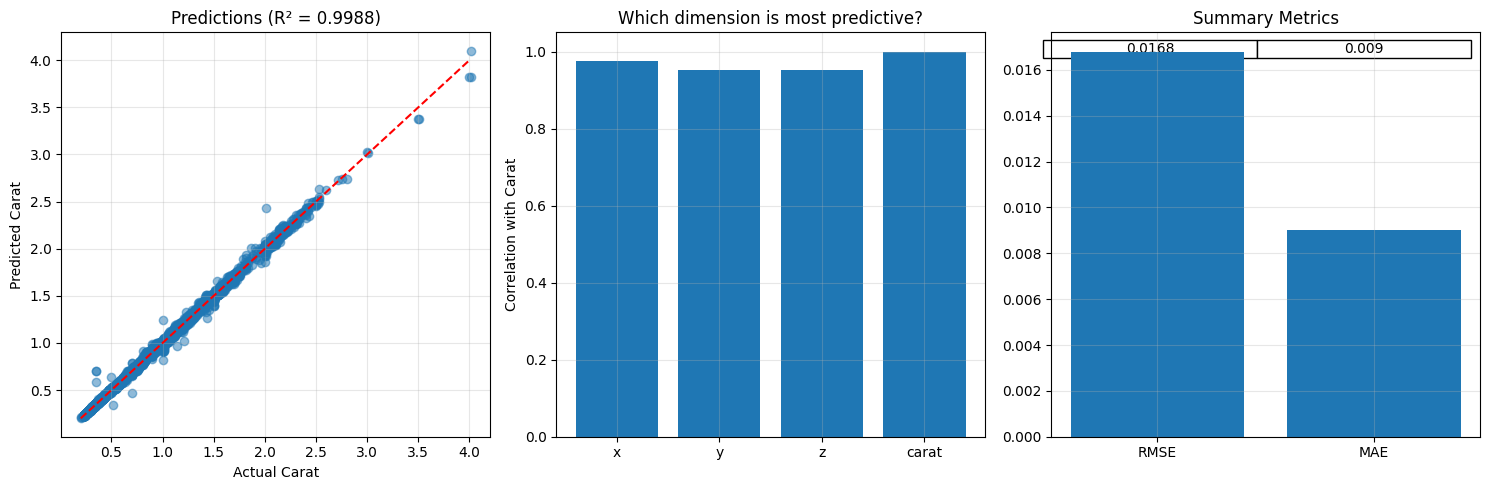

In [69]:
plt.figure(figsize=(15, 5))

# y_test vs y_pred
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Carat')
plt.ylabel('Predicted Carat')
plt.title(f'Predictions (R² = {r2:.4f})')
plt.grid(True, alpha=0.3)

# correlation
plt.subplot(1, 3, 2)
correlations = diamond[['x', 'y', 'z', 'carat']].corr()['carat']
plt.bar(correlations.index, correlations.values)
plt.ylabel('Correlation with Carat')
plt.title('Which dimension is most predictive?')
plt.grid(True, alpha=0.3)


# evaluation (errors)
plt.subplot(1, 3, 3)
metrics = ['RMSE', 'MAE']
values = [round(np.sqrt(mse), 4), round(mean_absolute_error(y_test, y_pred), 4)]
plt.bar(metrics, values)
plt.title('Summary Metrics')
plt.grid(True, alpha=0.3)
# plt.table(cellText=[values], loc='upper right', cellLoc='center')
plt.tight_layout()
plt.show()
